# ASIGNACIÓN #5 – Modelos de Agrupamiento: K-Means y DBSCAN

**Universidad Tecnológica de Panamá**  
**Facultad de Ingeniería de Sistemas Computacionales**  
**Curso:** Inteligencia Artificial  
**Profesor:** Ing. Manuel Paz

---

## Objetivo del trabajo

En este notebook se aplica clustering para separar clientes de un centro comercial en grupos con comportamientos parecidos. Para eso se usan dos algoritmos vistos en la asignatura: **K-Means** y **DBSCAN**.

La idea principal es revisar los datos, prepararlos, aplicar los modelos, interpretar los grupos encontrados y comparar cuál algoritmo resulta más fácil de entender para este caso.

## Dataset utilizado

Se utiliza el archivo **Mall_Customers.csv**, que contiene 200 clientes y las siguientes columnas:

- `CustomerID`: identificador del cliente.
- `Gender`: género del cliente.
- `Age`: edad.
- `Annual Income (k$)`: ingreso anual en miles de dólares.
- `Spending Score (1-100)`: puntaje de gasto asignado al cliente.



---

## Contenido del notebook

1. Importación de librerías
2. Carga y vista previa de los datos
3. Exploración y análisis de datos (EDA)
4. Limpieza y preparación de datos
5. K-Means Clustering (Elbow + Silhouette + interpretación)
6. DBSCAN Clustering (k-distance, sensibilidad de eps e interpretación)
7. Comparación entre K-Means y DBSCAN
8. Respuestas a las preguntas clave de la asignación
9. Cierre del trabajo


## 1. Importación de librerías



### Explicación de esta parte

Primero se importan las librerías necesarias para trabajar con los datos. `pandas` y `numpy` se usan para cargar y manipular la información. `matplotlib` y `seaborn` ayudan a crear las gráficas. De `scikit-learn` se toman los modelos de clustering, el escalador y las métricas que sirven para evaluar los resultados.

También se importa `NearestNeighbors` porque más adelante se usa para construir la gráfica de distancias que ayuda a escoger el valor de `eps` en DBSCAN.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 100
print('Librerias importadas correctamente.')



Librerias importadas correctamente.


## 2. Carga y vista previa de los datos



En esta parte se carga el archivo `Mall_Customers.csv`. Luego se revisa cuántas filas y columnas tiene el dataset y se muestran los primeros registros. Esto sirve para confirmar que el archivo se leyó correctamente antes de empezar el análisis.



In [2]:
df = pd.read_csv('Mall_Customers.csv')
print(f'Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas')
df.head(10)



Dimensiones: 200 filas x 5 columnas


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


## 3. Exploración y análisis de datos (EDA)

El EDA se realiza para entender mejor la información antes de aplicar los modelos. Aquí se revisan las variables, se buscan valores nulos o duplicados, se observan las distribuciones y se analiza si existen patrones visibles entre el ingreso anual y el puntaje de gasto.



### Revisión inicial del dataset

Primero se revisan los tipos de datos de cada columna y un resumen estadístico de las variables numéricas. Esto permite ver valores como la edad promedio, el ingreso promedio y el rango del puntaje de gasto.



In [3]:
print('=== Información del Dataset ===')
df.info()
print()
print('=== Estadísticas Descriptivas ===')
df.describe().round(2)



=== Información del Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

=== Estadísticas Descriptivas ===


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.00,200.00,200.00,200.00
mean,100.50,38.85,60.56,50.20
std,57.88,13.97,26.26,25.82
min,1.00,18.00,15.00,1.00
25%,50.75,28.75,41.50,34.75
50%,100.50,36.00,61.50,50.00
75%,150.25,49.00,78.00,73.00
max,200.00,70.00,137.00,99.00


### Calidad de los datos

Antes de entrenar los modelos se verifica si hay valores nulos o filas repetidas. Esto es importante porque los algoritmos pueden dar resultados incorrectos si los datos están incompletos o duplicados.



In [4]:
print('Valores nulos por columna:')
print(df.isnull().sum())
print(f'\nTotal de duplicados: {df.duplicated().sum()}')



Valores nulos por columna:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Total de duplicados: 0


### Distribución de las variables numéricas

Se crean histogramas para observar cómo se distribuyen la edad, el ingreso anual y el puntaje de gasto. Las líneas de media y mediana ayudan a notar si los datos están más concentrados hacia un lado o si se distribuyen de forma más equilibrada.



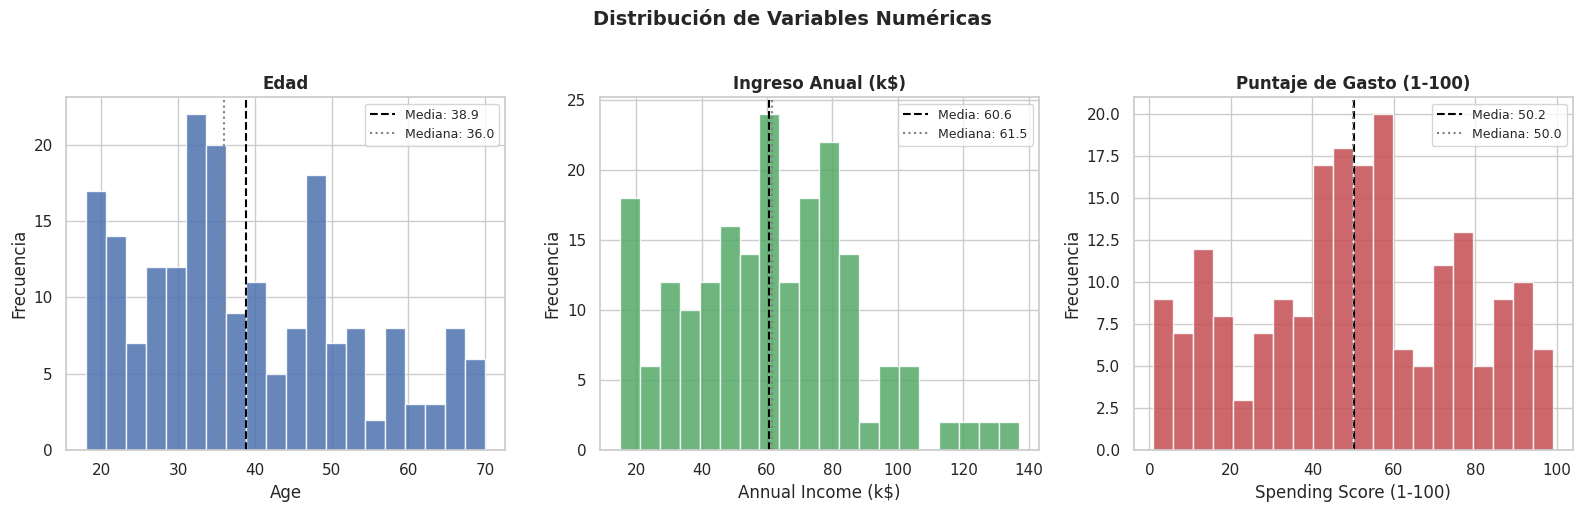

Las distribuciones muestran grupos naturales en ingreso y puntaje de gasto.


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cols   = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
colors = ['#4C72B0', '#55A868', '#C44E52']
titles = ['Edad', 'Ingreso Anual (k$)', 'Puntaje de Gasto (1-100)']

for ax, col, color, title in zip(axes, cols, colors, titles):
    ax.hist(df[col], bins=20, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(),   color='black', linestyle='--', lw=1.5,
               label=f'Media: {df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='gray',  linestyle=':',  lw=1.5,
               label=f'Mediana: {df[col].median():.1f}')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(col); ax.set_ylabel('Frecuencia'); ax.legend(fontsize=9)

plt.suptitle('Distribución de Variables Numéricas', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()
print('Las distribuciones muestran grupos naturales en ingreso y puntaje de gasto.')



### Distribución por género

En esta sección se revisa la cantidad de clientes por género y también se compara el puntaje de gasto según género. Esto ayuda a ver si existe alguna diferencia básica entre los grupos antes de aplicar clustering.



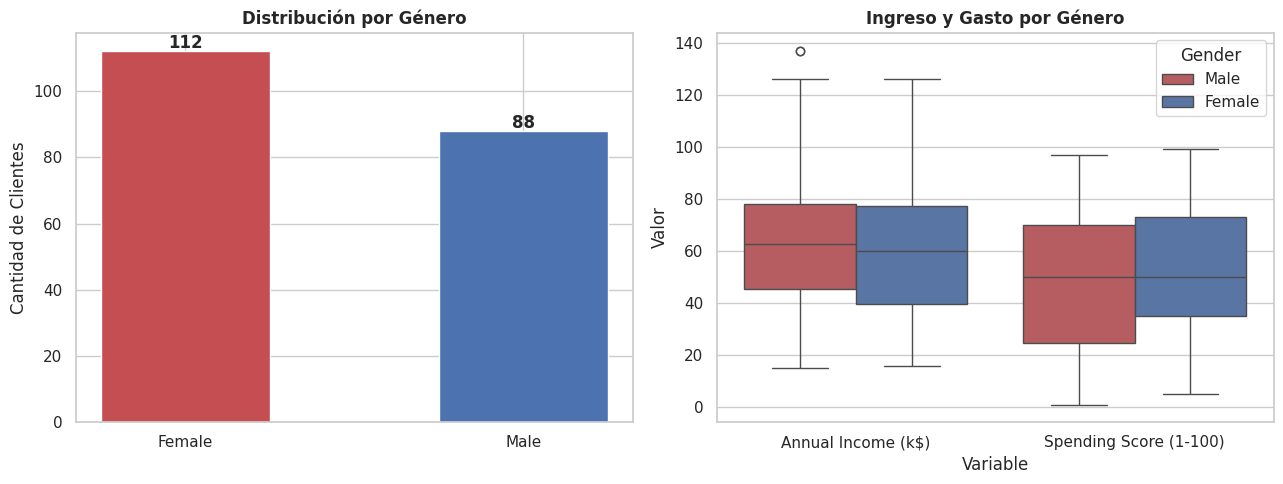

Distribución similar entre géneros en ingreso y puntaje de gasto.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

gender_counts = df['Gender'].value_counts()
axes[0].bar(gender_counts.index, gender_counts.values,
            color=['#C44E52','#4C72B0'], edgecolor='white', width=0.5)
axes[0].set_title('Distribución por Género', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Cantidad de Clientes')
for i, v in enumerate(gender_counts.values):
    axes[0].text(i, v+1, str(v), ha='center', fontweight='bold')

df_box = df[['Gender','Annual Income (k$)','Spending Score (1-100)']].melt(id_vars='Gender')
sns.boxplot(data=df_box, x='variable', y='value', hue='Gender', ax=axes[1],
            palette=['#C44E52','#4C72B0'])
axes[1].set_title('Ingreso y Gasto por Género', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Variable'); axes[1].set_ylabel('Valor')

plt.tight_layout(); plt.show()
print('Distribución similar entre géneros en ingreso y puntaje de gasto.')



### Matriz de correlación

La matriz de correlación muestra qué tan relacionadas están las variables numéricas. En este caso sirve para revisar si la edad, el ingreso y el puntaje de gasto tienen alguna relación fuerte entre sí.



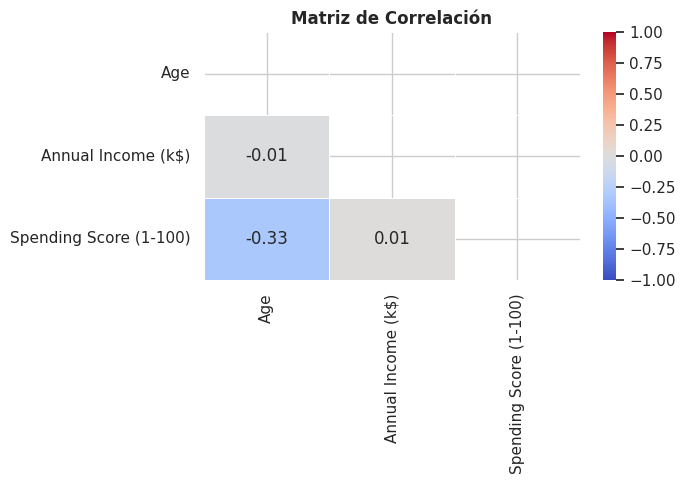

Baja correlación entre variables: cada una aporta información independiente.


In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
num_cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax, mask=mask, vmin=-1, vmax=1)
ax.set_title('Matriz de Correlación', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()
print('Baja correlación entre variables: cada una aporta información independiente.')



### Scatter plot de ingreso anual vs puntaje de gasto

Esta gráfica es una de las más importantes porque muestra la relación entre el ingreso anual y el puntaje de gasto. A simple vista se pueden notar zonas donde los clientes se agrupan, por eso estas dos variables se usan como base principal para los modelos.



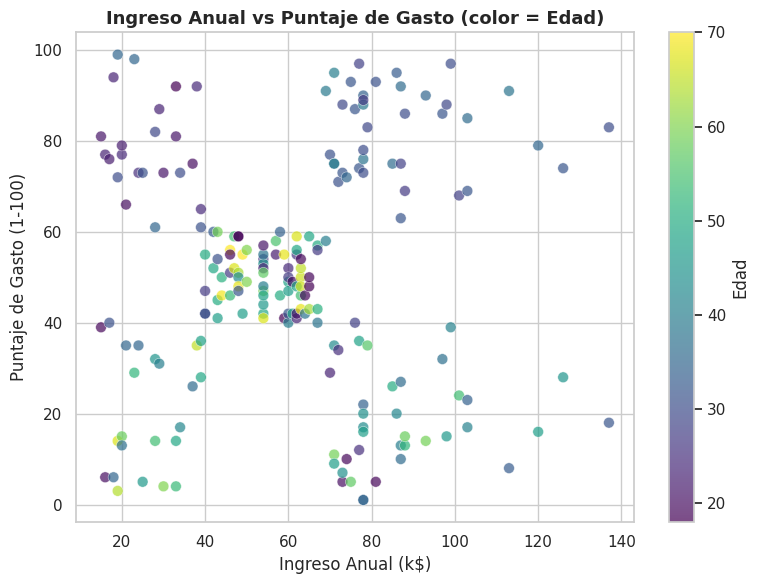

Se observan al menos 5 grupos naturales de clientes en el scatter plot.


In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'],
                     c=df['Age'], cmap='viridis', alpha=0.7, s=60, edgecolors='w', lw=0.4)
plt.colorbar(scatter, ax=ax, label='Edad')
ax.set_xlabel('Ingreso Anual (k$)', fontsize=12)
ax.set_ylabel('Puntaje de Gasto (1-100)', fontsize=12)
ax.set_title('Ingreso Anual vs Puntaje de Gasto (color = Edad)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
print('Se observan al menos 5 grupos naturales de clientes en el scatter plot.')



## 4. Limpieza y preparación de datos

Para aplicar clustering es necesario preparar los datos. En esta etapa se toman las siguientes decisiones:

1. **Eliminar `CustomerID` del entrenamiento:** esta columna solo identifica al cliente y no representa una característica de comportamiento.
2. **Codificar `Gender`:** como es una variable de texto, se convierte a número para poder analizarla.
3. **Seleccionar variables principales:** para los modelos se usan `Annual Income (k$)` y `Spending Score (1-100)`, porque permiten visualizar mejor los segmentos de clientes.
4. **Escalar los datos:** se usa `StandardScaler` para que las variables queden en una escala comparable y una variable no pese más que la otra solo por tener números más grandes.



### Preparación de los datos

Se crea una copia del dataset original para no modificar la información inicial. Luego se codifica el género, se separan las variables que se van a usar para clustering y se escalan los datos. Esta preparación se aplica antes de usar K-Means y DBSCAN.



In [9]:
df_clean = df.copy()
le = LabelEncoder()
df_clean['Gender_enc'] = le.fit_transform(df_clean['Gender'])  # Female=0, Male=1
print('Codificación: Female=0, Male=1')
print(df_clean[['Gender','Gender_enc']].drop_duplicates().to_string(index=False))

features_2d  = ['Annual Income (k$)', 'Spending Score (1-100)']
features_all = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender_enc']
X_2d  = df_clean[features_2d].values
X_all = df_clean[features_all].values

scaler_2d  = StandardScaler()
scaler_all = StandardScaler()
X_2d_scaled  = scaler_2d.fit_transform(X_2d)
X_all_scaled = scaler_all.fit_transform(X_all)

print(f'\nDataset escalado 2D  : {X_2d_scaled.shape}')
print(f'Dataset escalado All : {X_all_scaled.shape}')
print('Datos preparados y escalados correctamente.')



Codificación: Female=0, Male=1
Gender  Gender_enc
  Male           1
Female           0

Dataset escalado 2D  : (200, 2)
Dataset escalado All : (200, 4)
Datos preparados y escalados correctamente.


## 5. K-Means Clustering

K-Means es un algoritmo que divide los datos en un número fijo de grupos. Como este método necesita que se le indique cuántos clusters usar, primero se prueba con varios valores de K para decidir cuál funciona mejor.



### Selección del número óptimo de clusters (K)

Para escoger K se usan dos métodos:

- **Método del codo:** permite ver en qué punto la inercia deja de bajar de forma fuerte.
- **Silhouette Score:** ayuda a medir qué tan separados y definidos están los clusters.

Se prueban valores de K desde 2 hasta 10. En este caso, K=5 resulta una buena opción porque el método del codo muestra un cambio importante y el Silhouette Score es alto en comparación con los demás valores.



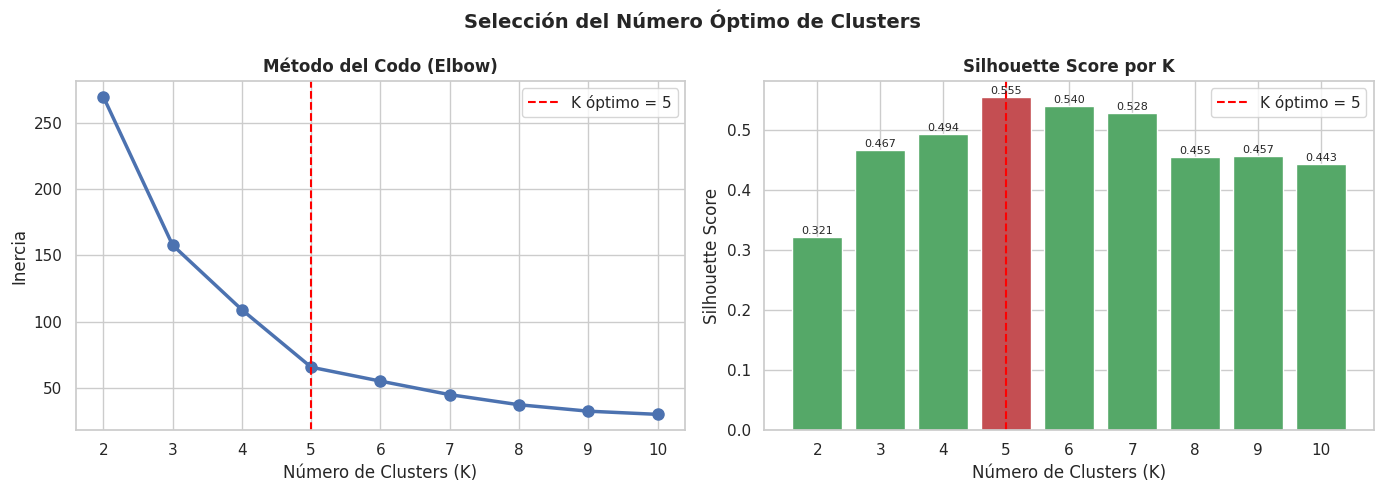


=== Tabla Resumen ===
 K  Inercia  Silhouette
 2    269.7      0.3213
 3    157.7      0.4666
 4    108.9      0.4939
 5     65.6      0.5547
 6     55.1      0.5399
 7     44.9      0.5281
 8     37.2      0.4552
 9     32.4      0.4571
10     30.0      0.4432

Conclusión: K=5 presenta el codo más marcado y Silhouette alto (0.555).


In [10]:
inertias, silhouettes = [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_2d_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_2d_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'o-', color='#4C72B0', lw=2.5, markersize=8)
axes[0].axvline(x=5, color='red', linestyle='--', lw=1.5, label='K óptimo = 5')
axes[0].set_title('Método del Codo (Elbow)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Número de Clusters (K)'); axes[0].set_ylabel('Inercia')
axes[0].legend(); axes[0].set_xticks(list(K_range))

axes[1].bar(K_range, silhouettes,
            color=['#C44E52' if k==5 else '#55A868' for k in K_range], edgecolor='white')
axes[1].axvline(x=5, color='red', linestyle='--', lw=1.5, label='K óptimo = 5')
axes[1].set_title('Silhouette Score por K', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Número de Clusters (K)'); axes[1].set_ylabel('Silhouette Score')
axes[1].legend(); axes[1].set_xticks(list(K_range))
for k, s in zip(K_range, silhouettes):
    axes[1].text(k, s+0.005, f'{s:.3f}', ha='center', fontsize=8)

plt.suptitle('Selección del Número Óptimo de Clusters', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print('\n=== Tabla Resumen ===')
summary = pd.DataFrame({'K': list(K_range),
                        'Inercia': [round(i,1) for i in inertias],
                        'Silhouette': [round(s,4) for s in silhouettes]})
print(summary.to_string(index=False))
print(f'\nConclusión: K=5 presenta el codo más marcado y Silhouette alto ({silhouettes[3]:.3f}).')



### Entrenamiento del modelo K-Means con K=5

Después de revisar las gráficas anteriores, se entrena el modelo final con **K=5**. También se calculan métricas como Silhouette Score y Davies-Bouldin para tener una idea más clara de la calidad del agrupamiento.



In [11]:
kmeans = KMeans(n_clusters=5, init='k-means++', n_init=10, random_state=42)
df_clean['KMeans_Cluster'] = kmeans.fit_predict(X_2d_scaled)

km_silhouette = silhouette_score(X_2d_scaled, df_clean['KMeans_Cluster'])
km_db_index   = davies_bouldin_score(X_2d_scaled, df_clean['KMeans_Cluster'])

print('=== Métricas del Modelo K-Means (K=5) ===')
print(f'  Inercia          : {kmeans.inertia_:.2f}')
print(f'  Silhouette Score : {km_silhouette:.4f}  (más cercano a 1 = mejor)')
print(f'  Davies-Bouldin   : {km_db_index:.4f}    (más cercano a 0 = mejor)')



=== Métricas del Modelo K-Means (K=5) ===
  Inercia          : 65.57
  Silhouette Score : 0.5547  (más cercano a 1 = mejor)
  Davies-Bouldin   : 0.5722    (más cercano a 0 = mejor)


### Visualización de los clusters de K-Means

En esta gráfica se muestran los cinco grupos encontrados por K-Means. Cada color representa un cluster y las marcas negras con forma de X representan los centroides, que son los puntos centrales de cada grupo.



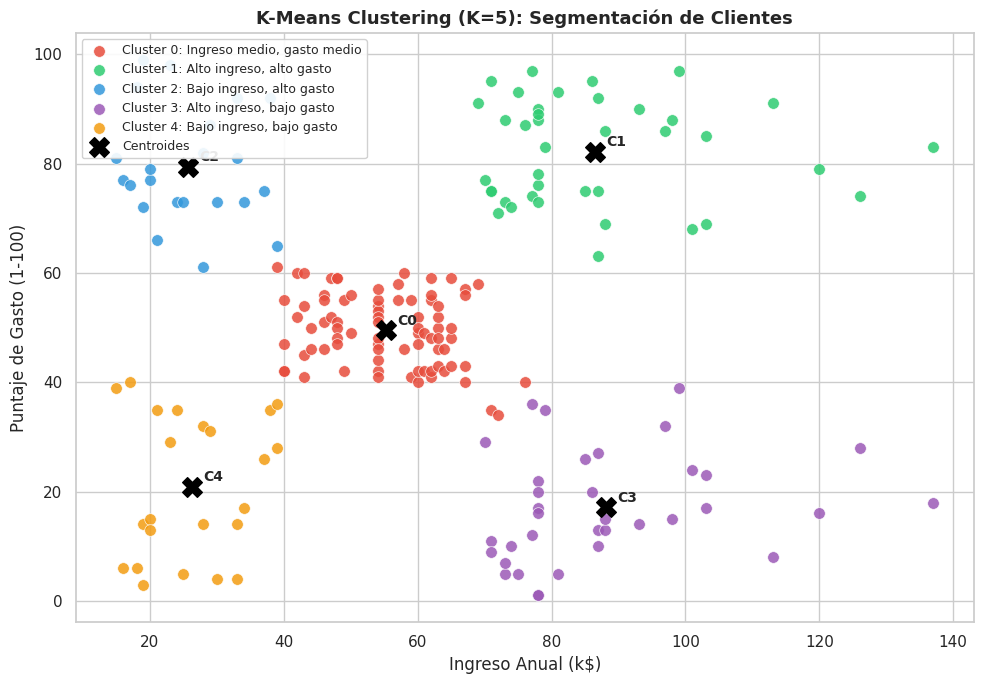

In [12]:
palette_km = {0:'#E74C3C', 1:'#2ECC71', 2:'#3498DB', 3:'#9B59B6', 4:'#F39C12'}
nombres_clusters = {
    0: 'Cluster 0: Ingreso medio, gasto medio',
    1: 'Cluster 1: Alto ingreso, alto gasto',
    2: 'Cluster 2: Bajo ingreso, alto gasto',
    3: 'Cluster 3: Alto ingreso, bajo gasto',
    4: 'Cluster 4: Bajo ingreso, bajo gasto'
}

fig, ax = plt.subplots(figsize=(10, 7))
for c in sorted(df_clean['KMeans_Cluster'].unique()):
    mask = df_clean['KMeans_Cluster'] == c
    ax.scatter(df_clean.loc[mask, 'Annual Income (k$)'],
               df_clean.loc[mask, 'Spending Score (1-100)'],
               c=palette_km[c], label=nombres_clusters[c],
               s=70, alpha=0.85, edgecolors='w', linewidths=0.5)

centroids_orig = scaler_2d.inverse_transform(kmeans.cluster_centers_)
ax.scatter(centroids_orig[:,0], centroids_orig[:,1],
           c='black', s=200, marker='X', zorder=5, label='Centroides')
for i,(x,y) in enumerate(centroids_orig):
    ax.annotate(f'C{i}', (x,y), textcoords='offset points', xytext=(8,4),
                fontsize=10, fontweight='bold')

ax.set_xlabel('Ingreso Anual (k$)', fontsize=12)
ax.set_ylabel('Puntaje de Gasto (1-100)', fontsize=12)
ax.set_title('K-Means Clustering (K=5): Segmentación de Clientes', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
plt.tight_layout(); plt.show()



### Perfil estadístico de los clusters

Aquí se calculan los promedios de edad, ingreso y puntaje de gasto para cada cluster. Con estos promedios se puede interpretar qué tipo de clientes representa cada grupo.



In [13]:
print('=== Perfil Estadístico de los Clusters K-Means ===\n')
profile = df_clean.groupby('KMeans_Cluster').agg(
    Cantidad      = ('CustomerID',            'count'),
    Edad_media    = ('Age',                   'mean'),
    Ingreso_medio = ('Annual Income (k$)',     'mean'),
    Gasto_medio   = ('Spending Score (1-100)', 'mean'),
    Pct_femenino  = ('Gender_enc', lambda x: f'{(x==0).mean()*100:.0f}%')
).round(1)
print(profile.to_string())
print("""
Interpretación:
  Cluster 0 - Ingreso medio, gasto medio : Clientes con comportamiento equilibrado o estándar.
  Cluster 1 - Alto ingreso, alto gasto   : Clientes premium, con alto poder adquisitivo y alto gasto.
  Cluster 2 - Bajo ingreso, alto gasto   : Clientes con bajo ingreso, pero con alto puntaje de gasto.
  Cluster 3 - Alto ingreso, bajo gasto   : Clientes con alto ingreso, pero bajo nivel de gasto.
  Cluster 4 - Bajo ingreso, bajo gasto   : Clientes conservadores, con bajo ingreso y bajo gasto.
""")


=== Perfil Estadístico de los Clusters K-Means ===

                Cantidad  Edad_media  Ingreso_medio  Gasto_medio Pct_femenino
KMeans_Cluster                                                               
0                     81        42.7           55.3         49.5          59%
1                     39        32.7           86.5         82.1          54%
2                     22        25.3           25.7         79.4          59%
3                     35        41.1           88.2         17.1          46%
4                     23        45.2           26.3         20.9          61%

Interpretación:
  Cluster 0 - Ingreso medio, gasto medio : Clientes con comportamiento equilibrado o estándar.
  Cluster 1 - Alto ingreso, alto gasto   : Clientes premium, con alto poder adquisitivo y alto gasto.
  Cluster 2 - Bajo ingreso, alto gasto   : Clientes con bajo ingreso, pero con alto puntaje de gasto.
  Cluster 3 - Alto ingreso, bajo gasto   : Clientes con alto ingreso, pero bajo nivel 

### ¿Qué ocurre si K cambia?

Para responder esta pregunta se comparan los resultados usando K=3, K=5 y K=7. La idea es observar que, si K es muy bajo, algunos grupos diferentes quedan mezclados. Si K es muy alto, se crean demasiados grupos y la interpretación se vuelve menos clara.



### Experimentando con diferentes valores de K

Se grafican tres resultados diferentes de K-Means. Esto permite ver visualmente por qué K=5 es más adecuado para este dataset, ya que mantiene una segmentación clara sin dividir demasiado los clientes.



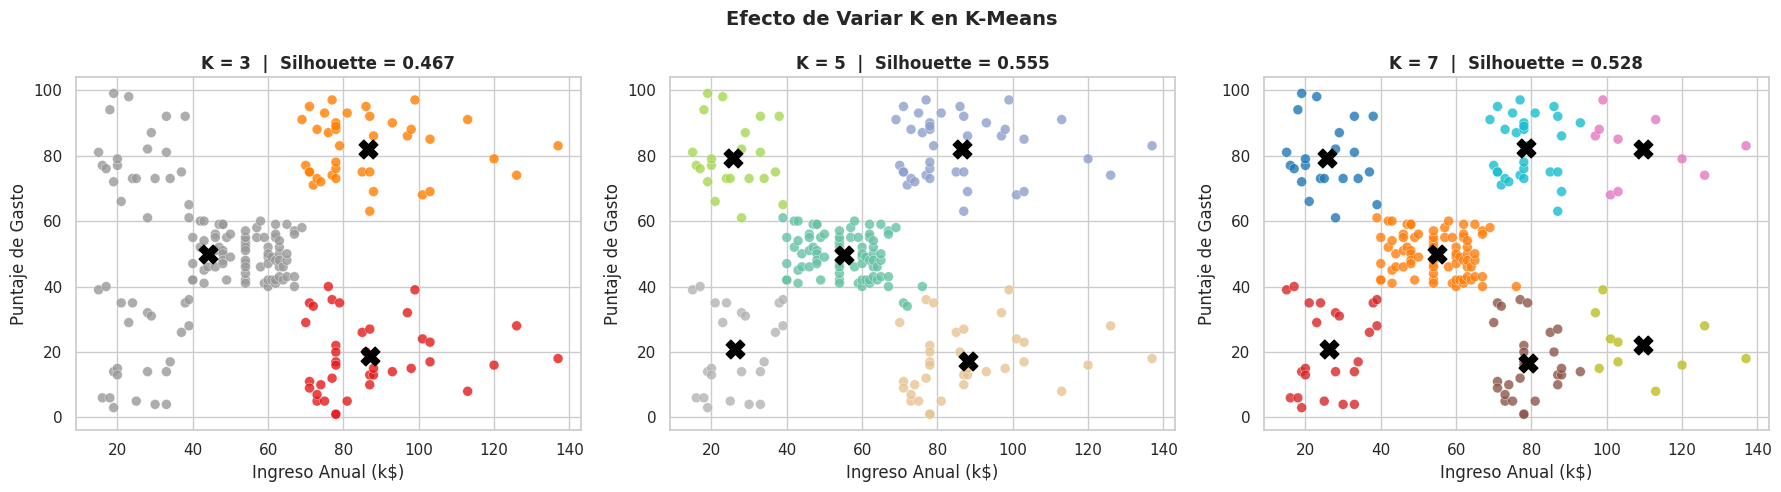

K=3: pierde distinciones. K=5: balance optimo. K=7: fragmenta grupos naturales.


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
palettes = {3:'Set1', 5:'Set2', 7:'tab10'}

for ax, k in zip(axes, [3, 5, 7]):
    km_test = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels  = km_test.fit_predict(X_2d_scaled)
    centroids = scaler_2d.inverse_transform(km_test.cluster_centers_)
    sil = silhouette_score(X_2d_scaled, labels)
    ax.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'],
               c=labels, cmap=palettes[k], alpha=0.8, s=50, edgecolors='w', lw=0.3)
    ax.scatter(centroids[:,0], centroids[:,1], c='black', s=180, marker='X', zorder=5)
    ax.set_title(f'K = {k}  |  Silhouette = {sil:.3f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Ingreso Anual (k$)'); ax.set_ylabel('Puntaje de Gasto')

plt.suptitle('Efecto de Variar K en K-Means', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
print('K=3: pierde distinciones. K=5: balance optimo. K=7: fragmenta grupos naturales.')



## 6. DBSCAN Clustering

DBSCAN es un algoritmo basado en densidad. A diferencia de K-Means, no se le indica directamente cuántos clusters debe crear. En su lugar, usa dos parámetros principales:

- `eps`: distancia máxima para considerar que dos puntos están cerca.
- `min_samples`: cantidad mínima de puntos necesarios para formar una zona densa.

Una ventaja de DBSCAN es que puede marcar algunos puntos como ruido u outliers cuando no pertenecen a una zona densa.



### Selección de `eps` con el k-distance graph

Para escoger `eps` se usa una gráfica de distancias al vecino más cercano. Se coloca `min_samples=5` y se observa dónde aparece un cambio o "codo" en la curva. Según la gráfica, se toma `eps=0.50` como valor adecuado para este caso.



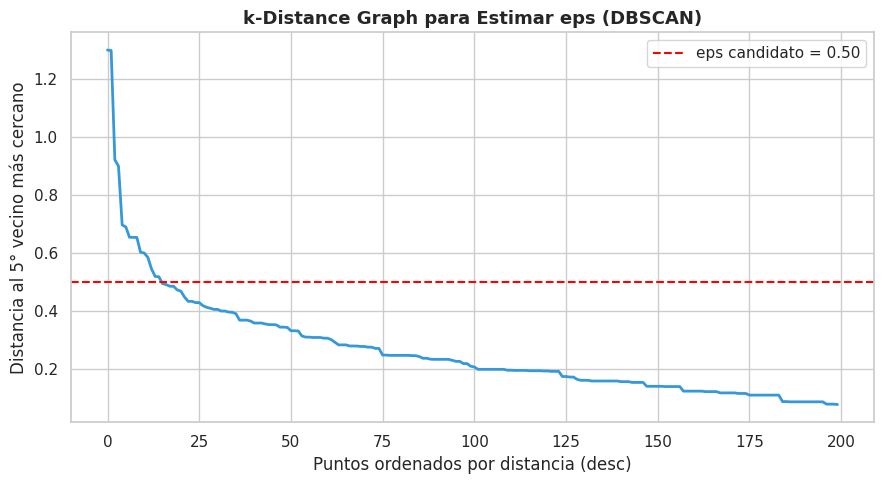

El codo se observa alrededor de eps ~ 0.50 con min_samples=5.


In [15]:
min_samples = 5

nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X_2d_scaled)
distances, _ = nbrs.kneighbors(X_2d_scaled)
k_distances = np.sort(distances[:, -1])[::-1]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(k_distances, color='#3498DB', lw=2)
ax.axhline(y=0.5, color='red', linestyle='--', lw=1.5, label='eps candidato = 0.50')
ax.set_title('k-Distance Graph para Estimar eps (DBSCAN)', fontsize=13, fontweight='bold')
ax.set_xlabel('Puntos ordenados por distancia (desc)')
ax.set_ylabel(f'Distancia al {min_samples}° vecino más cercano')
ax.legend(fontsize=11)
plt.tight_layout(); plt.show()
print(f'El codo se observa alrededor de eps ~ 0.50 con min_samples={min_samples}.')



### Entrenamiento del modelo DBSCAN

Con `eps=0.50` y `min_samples=5` se entrena DBSCAN. El modelo asigna una etiqueta a cada cliente. La etiqueta `-1` significa que el cliente fue considerado ruido u outlier.



In [16]:
dbscan = DBSCAN(eps=0.50, min_samples=5)
df_clean['DBSCAN_Cluster'] = dbscan.fit_predict(X_2d_scaled)

n_clusters = len(set(df_clean['DBSCAN_Cluster'])) - (1 if -1 in df_clean['DBSCAN_Cluster'].values else 0)
n_noise    = (df_clean['DBSCAN_Cluster'] == -1).sum()

print('=== Resultados DBSCAN (eps=0.50, min_samples=5) ===')
print(f'  Clusters encontrados : {n_clusters}')
print(f'  Outliers (ruido)     : {n_noise} ({n_noise/len(df_clean)*100:.1f}%)')
print('\nDistribución de etiquetas:')
print(df_clean['DBSCAN_Cluster'].value_counts().sort_index().to_string())

mask_valid = df_clean['DBSCAN_Cluster'] != -1
if mask_valid.sum() > 1 and n_clusters > 1:
    db_sil = silhouette_score(X_2d_scaled[mask_valid],
                              df_clean.loc[mask_valid, 'DBSCAN_Cluster'])
    print(f'\n  Silhouette Score (sin outliers): {db_sil:.4f}')



=== Resultados DBSCAN (eps=0.50, min_samples=5) ===
  Clusters encontrados : 2
  Outliers (ruido)     : 8 (4.0%)

Distribución de etiquetas:
DBSCAN_Cluster
-1      8
 0    157
 1     35

  Silhouette Score (sin outliers): 0.3876


### Visualización de los clusters DBSCAN

En esta gráfica se observan los grupos encontrados por DBSCAN. Los puntos marcados como `x` representan los outliers. Estos puntos no fueron asignados a un cluster principal porque no están dentro de una zona suficientemente densa.



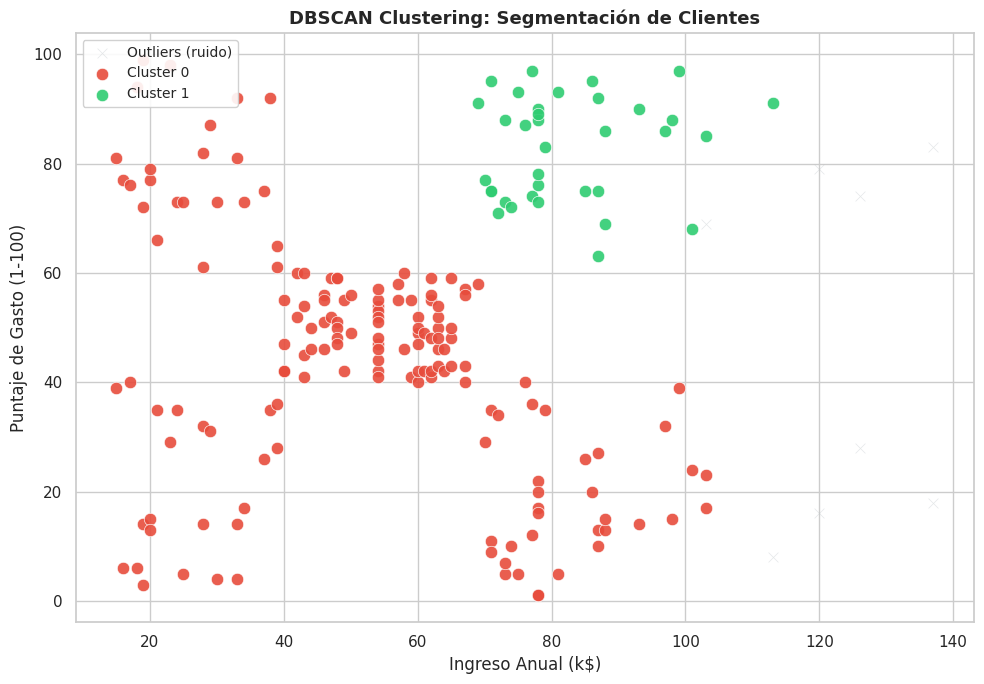

In [17]:
palette_db = {-1:'#BDC3C7', 0:'#E74C3C', 1:'#2ECC71', 2:'#3498DB', 3:'#9B59B6', 4:'#F39C12'}
labels_db  = {-1:'Outliers (ruido)', 0:'Cluster 0', 1:'Cluster 1',
               2:'Cluster 2', 3:'Cluster 3', 4:'Cluster 4'}

fig, ax = plt.subplots(figsize=(10, 7))
for c in sorted(df_clean['DBSCAN_Cluster'].unique()):
    mask = df_clean['DBSCAN_Cluster'] == c
    ax.scatter(df_clean.loc[mask, 'Annual Income (k$)'],
               df_clean.loc[mask, 'Spending Score (1-100)'],
               c=palette_db.get(c, '#95A5A6'),
               label=labels_db.get(c, f'Cluster {c}'),
               s=80 if c != -1 else 50,
               alpha=0.9 if c != -1 else 0.4,
               marker='o' if c != -1 else 'x',
               edgecolors='w' if c != -1 else 'none', lw=0.5)

ax.set_xlabel('Ingreso Anual (k$)', fontsize=12)
ax.set_ylabel('Puntaje de Gasto (1-100)', fontsize=12)
ax.set_title('DBSCAN Clustering: Segmentación de Clientes', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=10, framealpha=0.9)
plt.tight_layout(); plt.show()



### Perfil estadístico de los clusters DBSCAN

Se calculan los promedios de los clusters encontrados por DBSCAN, incluyendo el grupo de ruido. Esto ayuda a entender qué características tienen los clientes normales y qué características tienen los clientes atípicos.



In [18]:
print('=== Perfil Estadístico de los Clusters DBSCAN ===\n')
profile_db = df_clean.groupby('DBSCAN_Cluster').agg(
    Cantidad      = ('CustomerID',            'count'),
    Edad_media    = ('Age',                   'mean'),
    Ingreso_medio = ('Annual Income (k$)',     'mean'),
    Gasto_medio   = ('Spending Score (1-100)', 'mean')
).round(1)
profile_db.index = ['Ruido (-1)' if i==-1 else f'Cluster {i}' for i in profile_db.index]
print(profile_db.to_string())
print("""
Interpretación de outliers (-1):
  DBSCAN detectó 8 clientes como ruido. Estos clientes tienen combinaciones atípicas
  de ingreso y gasto, por eso no quedaron dentro de una zona densa. En una situación real
  se podrían revisar individualmente porque se comportan diferente al resto.

Ventajas de DBSCAN:
  [+] No requiere especificar K desde el inicio.
  [+] Puede detectar puntos atípicos automáticamente.
  [+] Trabaja con zonas densas de datos.
  [-] Es sensible a la elección de eps y min_samples.
""")


=== Perfil Estadístico de los Clusters DBSCAN ===

            Cantidad  Edad_media  Ingreso_medio  Gasto_medio
Ruido (-1)         8        35.8          122.8         46.9
Cluster 0        157        40.4           52.5         43.1
Cluster 1         35        32.7           82.5         82.8

Interpretación de outliers (-1):
  DBSCAN detectó 8 clientes como ruido. Estos clientes tienen combinaciones atípicas
  de ingreso y gasto, por eso no quedaron dentro de una zona densa. En una situación real
  se podrían revisar individualmente porque se comportan diferente al resto.

Ventajas de DBSCAN:
  [+] No requiere especificar K desde el inicio.
  [+] Puede detectar puntos atípicos automáticamente.
  [+] Trabaja con zonas densas de datos.
  [-] Es sensible a la elección de eps y min_samples.



### Análisis de sensibilidad del parámetro `eps`

Para reforzar la elección de `eps=0.50` se prueban varios valores manteniendo `min_samples=5`. Esto demuestra de forma cuantitativa cómo cambia el número de clusters y de outliers según el valor de `eps`, y por qué el valor escogido ofrece el mejor equilibrio.

In [19]:
print('=== Sensibilidad de eps (min_samples = 5) ===\n')
resultados_eps = []
for eps_test in [0.3, 0.4, 0.5, 0.6, 0.7]:
    db_t = DBSCAN(eps=eps_test, min_samples=5).fit(X_2d_scaled)
    lbl  = db_t.labels_
    n_cl = len(set(lbl)) - (1 if -1 in lbl else 0)
    n_no = int((lbl == -1).sum())
    sil  = (silhouette_score(X_2d_scaled[lbl != -1], lbl[lbl != -1])
            if n_cl >= 2 else np.nan)
    resultados_eps.append({
        'eps': eps_test, 'Clusters': n_cl, 'Outliers': n_no,
        'Silhouette': round(sil, 4) if not np.isnan(sil) else None
    })

tabla_eps = pd.DataFrame(resultados_eps)
print(tabla_eps.to_string(index=False))
print('''
Lectura de la tabla:
  - eps muy bajo (0.30): demasiados puntos quedan como ruido (outliers).
  - eps muy alto (0.70): casi todos los puntos se unen en un solo cluster.
  - eps = 0.50: equilibra el numero de clusters y la cantidad de outliers,
    coincidiendo con el codo observado en el k-distance graph.''')

=== Sensibilidad de eps (min_samples = 5) ===

 eps  Clusters  Outliers  Silhouette
 0.3         7        35      0.5243
 0.4         4        15      0.4781
 0.5         2         8      0.3876
 0.6         1         5         NaN
 0.7         1         0         NaN

Lectura de la tabla:
  - eps muy bajo (0.30): demasiados puntos quedan como ruido (outliers).
  - eps muy alto (0.70): casi todos los puntos se unen en un solo cluster.
  - eps = 0.50: equilibra el numero de clusters y la cantidad de outliers,
    coincidiendo con el codo observado en el k-distance graph.


## 7. Comparación entre K-Means y DBSCAN



### Visualización comparativa lado a lado

Se colocan las gráficas de K-Means y DBSCAN una al lado de la otra. Esto facilita comparar cómo cada algoritmo separa los clientes y cómo DBSCAN identifica puntos atípicos.



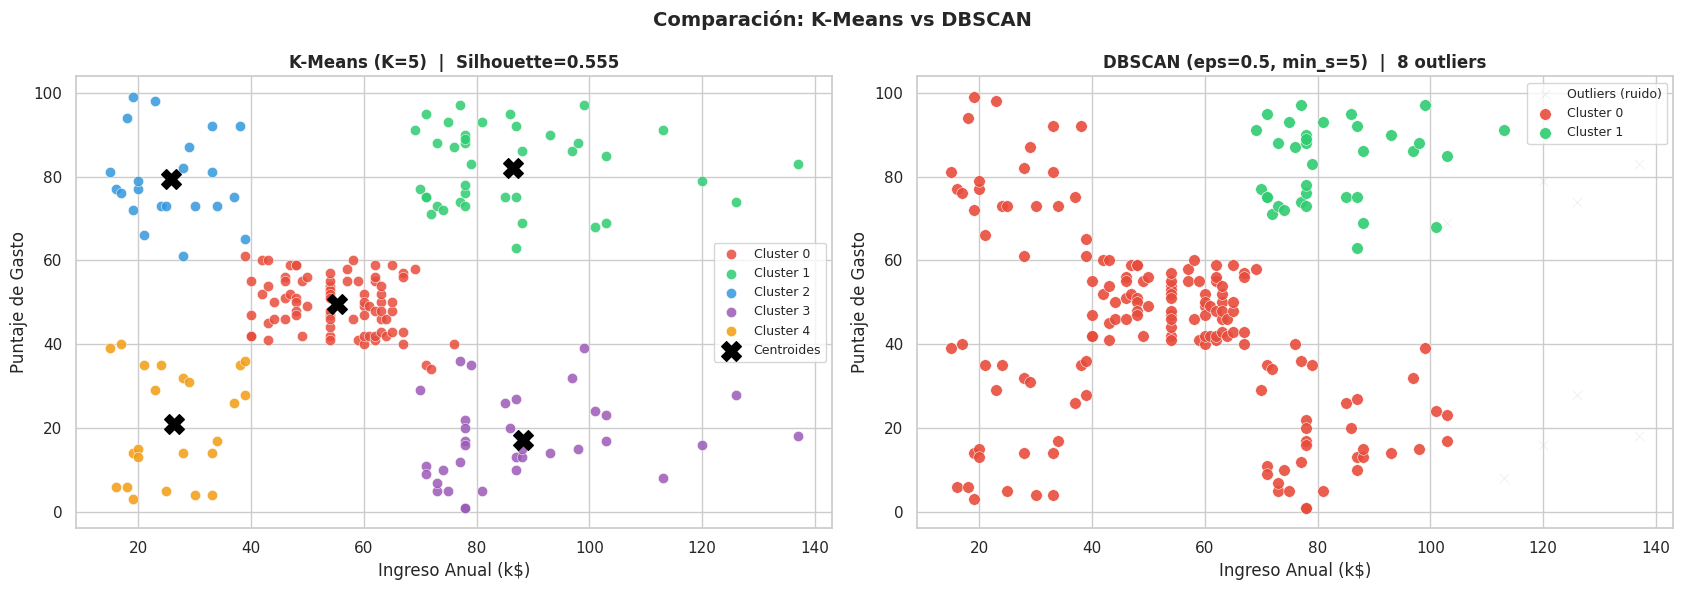

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# K-Means
for c in sorted(df_clean['KMeans_Cluster'].unique()):
    mask = df_clean['KMeans_Cluster'] == c
    axes[0].scatter(df_clean.loc[mask, 'Annual Income (k$)'],
                    df_clean.loc[mask, 'Spending Score (1-100)'],
                    c=palette_km[c], label=f'Cluster {c}',
                    s=55, alpha=0.85, edgecolors='w', lw=0.4)
axes[0].scatter(centroids_orig[:,0], centroids_orig[:,1],
                c='black', s=200, marker='X', zorder=5, label='Centroides')
axes[0].set_title(f'K-Means (K=5)  |  Silhouette={km_silhouette:.3f}',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Ingreso Anual (k$)'); axes[0].set_ylabel('Puntaje de Gasto')
axes[0].legend(fontsize=9)

# DBSCAN
for c in sorted(df_clean['DBSCAN_Cluster'].unique()):
    mask = df_clean['DBSCAN_Cluster'] == c
    axes[1].scatter(df_clean.loc[mask, 'Annual Income (k$)'],
                    df_clean.loc[mask, 'Spending Score (1-100)'],
                    c=palette_db.get(c,'#95A5A6'),
                    label=labels_db.get(c, f'Cluster {c}'),
                    s=70 if c!=-1 else 45,
                    alpha=0.9 if c!=-1 else 0.4,
                    marker='o' if c!=-1 else 'x',
                    edgecolors='w' if c!=-1 else 'none', lw=0.4)
axes[1].set_title(f'DBSCAN (eps=0.5, min_s=5)  |  {n_noise} outliers',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Ingreso Anual (k$)'); axes[1].set_ylabel('Puntaje de Gasto')
axes[1].legend(fontsize=9)

plt.suptitle('Comparación: K-Means vs DBSCAN', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()



### Comparación cuantitativa de métricas

Además de comparar las gráficas, se calculan métricas para los dos algoritmos. El Silhouette Score sirve para medir qué tan bien separados están los clusters. El índice Davies-Bouldin se interpreta al contrario: mientras más bajo, mejor separación entre grupos.



In [21]:
mask_valid = df_clean['DBSCAN_Cluster'] != -1
db_sil2 = silhouette_score(X_2d_scaled[mask_valid],
                            df_clean.loc[mask_valid, 'DBSCAN_Cluster'])
db_dbi2 = davies_bouldin_score(X_2d_scaled[mask_valid],
                                df_clean.loc[mask_valid, 'DBSCAN_Cluster'])

comparacion = pd.DataFrame({
    'Algoritmo'        : ['K-Means (K=5)', 'DBSCAN (eps=0.5)'],
    'Clusters'         : [5, n_clusters],
    'Outliers'         : [0, n_noise],
    'Silhouette Score' : [round(km_silhouette,4), round(db_sil2,4)],
    'Davies-Bouldin'   : [round(km_db_index,4),   round(db_dbi2,4)],
    'Requiere K'       : ['Si', 'No'],
    'Detecta outliers' : ['No', 'Si'],
    'Forma clusters'   : ['Esférica', 'Arbitraria']
})
print('=== Tabla Comparativa de Algoritmos ===\n')
print(comparacion.to_string(index=False))



=== Tabla Comparativa de Algoritmos ===

       Algoritmo  Clusters  Outliers  Silhouette Score  Davies-Bouldin Requiere K Detecta outliers Forma clusters
   K-Means (K=5)         5         0            0.5547          0.5722         Si               No       Esférica
DBSCAN (eps=0.5)         2         8            0.3876          0.7889         No               Si     Arbitraria


### Conclusiones de la comparación

| Aspecto | K-Means | DBSCAN |
|---------|---------|--------|
| **Parámetros** | Necesita escoger K antes de entrenar | Necesita escoger `eps` y `min_samples` |
| **Forma de clusters** | Funciona mejor con grupos compactos o parecidos a círculos | Puede detectar grupos por densidad |
| **Outliers** | Asigna todos los puntos a un cluster | Separa automáticamente los puntos de ruido |
| **Resultado en este dataset** | Genera 5 segmentos claros y fáciles de interpretar | Encuentra 2 clusters principales y 8 outliers |
| **Uso recomendado aquí** | Más útil para segmentación de clientes | Útil como apoyo para detectar clientes atípicos |

**Conclusión general:** para este dataset, **K-Means con K=5** es más fácil de interpretar para segmentación de clientes. **DBSCAN** también aporta información importante porque detecta 8 clientes atípicos que podrían analizarse de forma individual.



## 8. Respuestas a las preguntas clave de la asignación

### Sobre K-Means

**¿Cómo eligieron K?**  
Se eligió K usando el método del codo y el Silhouette Score. Se probaron valores desde K=2 hasta K=10. El valor K=5 fue seleccionado porque en la gráfica del codo se observa una disminución importante de la inercia hasta ese punto, y además el Silhouette Score para K=5 fue alto, aproximadamente 0.555.

**¿Qué representa cada cluster?**  
- **Cluster 0: Ingreso medio, gasto medio.** Representa clientes con comportamiento equilibrado o estándar. No tienen ni el gasto más alto ni el más bajo.
- **Cluster 1: Alto ingreso, alto gasto.** Representa clientes premium, con buen poder adquisitivo y alto puntaje de gasto. Son clientes importantes para campañas de marketing.
- **Cluster 2: Bajo ingreso, alto gasto.** Representa clientes con menor ingreso, pero con alto puntaje de gasto. Pueden ser compradores impulsivos o clientes jóvenes que gastan bastante dentro del centro comercial.
- **Cluster 3: Alto ingreso, bajo gasto.** Representa clientes con alto ingreso, pero bajo puntaje de gasto. Pueden ser clientes ahorradores o personas que todavía no compran mucho en el centro comercial.
- **Cluster 4: Bajo ingreso, bajo gasto.** Representa clientes con menor ingreso y bajo puntaje de gasto. Son clientes más conservadores en su consumo.

**¿Qué ocurre si K cambia?**  
Si K es menor que 5, algunos segmentos diferentes se mezclan y se pierde detalle en la interpretación. Si K es mayor que 5, los grupos se dividen demasiado y puede ser más difícil explicar qué representa cada cluster. Por eso K=5 da un balance adecuado entre detalle y claridad.

---

### Sobre DBSCAN

**¿Cómo seleccionaron `eps`?**  
Se usó el k-distance graph con `min_samples=5`. En la curva se observó un cambio alrededor de 0.50, por eso se seleccionó `eps=0.50`. Este valor permite formar zonas densas sin marcar demasiados clientes como ruido.

**¿Qué representan los outliers?**  
Los **8 puntos con etiqueta -1** representan clientes con combinaciones atípicas de ingreso, edad, género y puntaje de gasto. Estos clientes no pertenecen a una región suficientemente densa según los parámetros usados en DBSCAN. En un caso real, podrían revisarse de forma individual porque tienen un comportamiento diferente al resto.

**¿Qué ventajas tiene DBSCAN sobre K-Means?**  
DBSCAN tiene varias ventajas: no necesita que se indique el número de clusters desde el inicio, puede detectar outliers automáticamente y trabaja con la idea de densidad. En cambio, K-Means siempre asigna todos los puntos a un cluster, aunque algunos clientes sean atípicos.

---

## 9. Cierre del trabajo

El notebook cumple con el objetivo de aplicar modelos de agrupamiento y comparar su comportamiento. K-Means permitió obtener una segmentación clara de 5 tipos de clientes. DBSCAN encontró menos clusters principales, pero ayudó a identificar 8 clientes atípicos. En conclusión, para este dataset K-Means resulta más práctico para segmentación general, mientras que DBSCAN es útil para detectar casos especiales.

